# CrediFlux — Phase 3: Deeper Exploratory Data Analysis (EDA)

This notebook is part of the **CrediFlux** credit risk assessment and loan default prediction project.

### 🎯 Notebook Objective
The primary objective of this notebook is to perform a comprehensive, research-grade Exploratory Data Analysis on the resolved loan dataset to uncover key distributional patterns, risk factors, multicollinearity structures, and anomalies that will directly inform the upcoming feature engineering and XGBoost modeling stages.

---

### 📋 Constraints & Scope
- **Data Reuse:** Directly utilizes the representative 50K stratified sample (`data/crediflux_50k.csv`) and the resolved loan subset (`loan_status` $\in \{\text{Fully Paid, Charged Off}\}$).
- **No Modeling:** No machine learning models are trained in this notebook.
- **No In-Place Modification:** Observations are inspected and anomalies are documented, but no rows or columns are altered or removed.
- **No Premature Processing:** No feature engineering, encoding, SMOTE/class-weighting, or threshold optimization is applied at this stage.

## 1. Environment Setup & Data Loading

We import the required data manipulation, statistical analysis, and visualization libraries. We configure clean, presentation-ready plotting styles with Seaborn and Matplotlib.

In [1]:
# Environment Setup
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

# Visual style configuration
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid", palette="muted")
palette = {'Non-Default (0)': '#2b5c8f', 'Default (1)': '#d95f02'}
custom_colors = ['#2b5c8f', '#d95f02', '#7570b3', '#e7298a', '#66a61e', '#e6ab02']

### Load Representative 50K Dataset and Isolate Resolved Outcomes
We load `crediflux_50k.csv` and filter the records to resolved loans (`Fully Paid` and `Charged Off`), defining our binary target variable:
- **`0` = Fully Paid (Non-Default)**
- **`1` = Charged Off (Default)**

In [2]:
# Load dataset
data_paths = [
    os.path.join("data", "crediflux_50k.csv"),
    os.path.join("..", "data", "crediflux_50k.csv")
]
data_path = next((p for p in data_paths if os.path.exists(p)), None)

if data_path is None:
    raise FileNotFoundError("Dataset crediflux_50k.csv not found in data/ or ../data/")

print(f"Loading dataset from: {data_path}")
df_raw = pd.read_csv(data_path, low_memory=False)
print(f"Raw 50K Sample Shape: {df_raw.shape}")

# Filter to resolved loans (Fully Paid vs Charged Off)
df = df_raw[df_raw['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# Create binary target
df['target'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

print(f"Resolved Loans Subset Shape: {df.shape}")
print(f"Columns: {df.shape[1]} (including target)")

Loading dataset from: ..\data\crediflux_50k.csv


Raw 50K Sample Shape: (50000, 151)
Resolved Loans Subset Shape: (29754, 152)
Columns: 152 (including target)


## 2. Data Quality & Structural Overview

Before diving into feature distributions, we perform an empirical audit of the dataset structure, data types, missing value prevalence, duplicate rows, and general integrity.

In [3]:
# Data types breakdown
dtype_counts = df.dtypes.value_counts()
print("--- Data Types Breakdown ---")
for dtype, count in dtype_counts.items():
    print(f"  {str(dtype):15s}: {count:3d} columns")

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows in Resolved Dataset: {duplicate_count}")

# Missing values audit across all 151 original columns
missing_counts = df.isnull().sum()
missing_pcts = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_pcts
}).sort_values(by='Missing Percentage (%)', ascending=False)

# Categorize missingness severity
zero_missing = missing_summary[missing_summary['Missing Percentage (%)'] == 0]
low_missing = missing_summary[(missing_summary['Missing Percentage (%)'] > 0) & (missing_summary['Missing Percentage (%)'] <= 20)]
moderate_missing = missing_summary[(missing_summary['Missing Percentage (%)'] > 20) & (missing_summary['Missing Percentage (%)'] <= 80)]
severe_missing = missing_summary[missing_summary['Missing Percentage (%)'] > 80]

print(f"\n--- Missingness Hierarchy across all {len(df.columns)} columns ---")
print(f"  Complete columns (0% missing):        {len(zero_missing):3d} columns")
print(f"  Low missingness (<= 20% missing):     {len(low_missing):3d} columns")
print(f"  Moderate missingness (20-80% missing):{len(moderate_missing):3d} columns")
print(f"  Severe missingness (> 80% missing):    {len(severe_missing):3d} columns")

--- Data Types Breakdown ---
  float64        : 113 columns
  object         :  38 columns
  int64          :   1 columns

Duplicate Rows in Resolved Dataset: 0



--- Missingness Hierarchy across all 152 columns ---
  Complete columns (0% missing):         52 columns
  Low missingness (<= 20% missing):      42 columns
  Moderate missingness (20-80% missing): 18 columns
  Severe missingness (> 80% missing):     40 columns


### Key Features Missingness Table
We inspect missingness specifically for key candidate numerical and categorical features available at origination.

In [4]:
candidate_cols = [
    'loan_amnt', 'annual_inc', 'int_rate', 'installment', 'dti',
    'fico_range_low', 'fico_range_high', 'revol_bal', 'revol_util',
    'open_acc', 'total_acc', 'delinq_2yrs',
    'grade', 'sub_grade', 'home_ownership', 'verification_status',
    'purpose', 'term', 'emp_length', 'application_type'
]

key_missing = missing_summary.loc[candidate_cols]
key_missing['Data Type'] = df[candidate_cols].dtypes
key_missing['Unique Values'] = df[candidate_cols].nunique()
key_missing = key_missing.reset_index().rename(columns={'index': 'Feature'})

display(key_missing[['Feature', 'Data Type', 'Unique Values', 'Missing Count', 'Missing Percentage (%)']])

,Feature,Data Type,Unique Values,Missing Count,Missing Percentage (%)
0,loan_amnt,float64,1218,0,0.000000
1,annual_inc,float64,3466,0,0.000000
2,int_rate,float64,503,0,0.000000
3,installment,float64,13898,0,0.000000
4,dti,float64,3946,6,0.020165
5,fico_range_low,float64,38,0,0.000000
6,fico_range_high,float64,38,0,0.000000
7,revol_bal,float64,19569,0,0.000000
8,revol_util,float64,1050,26,0.087383
9,open_acc,float64,52,0,0.000000


### 💡 Data Quality Insights
1. **Zero Duplicates:** The 29,754 resolved loan records contain zero exact duplicate rows.
2. **High Completeness in Core Predictors:** Almost all core numerical features have **0.0% missing values**, with only minor exceptions: `dti` (6 missing rows, 0.02%) and `revol_util` (26 missing rows, 0.09%).
3. **Missingness in Categorical Predictors:** `emp_length` has 1,729 missing values (5.81%), corresponding to borrowers where employment duration was unrecorded or self-employed without tenure records. All other core categorical fields (`grade`, `home_ownership`, `purpose`, etc.) have complete coverage (0% missing).
4. **Severe Missingness in Secondary Fields:** Many secondary columns in the Lending Club dataset (e.g., joint credit fields, hardship flags, settlement fields) have >80% missingness, confirming that strict feature selection is essential before modeling.

## 3. Target Distribution & Class Imbalance Analysis

We evaluate the distribution of the binary credit default target (`target`).

,Loan Status,Count,Percentage (%)
0,"Fully Paid (Non-Default, 0)",23814,80.036298
1,"Charged Off (Default, 1)",5940,19.963702


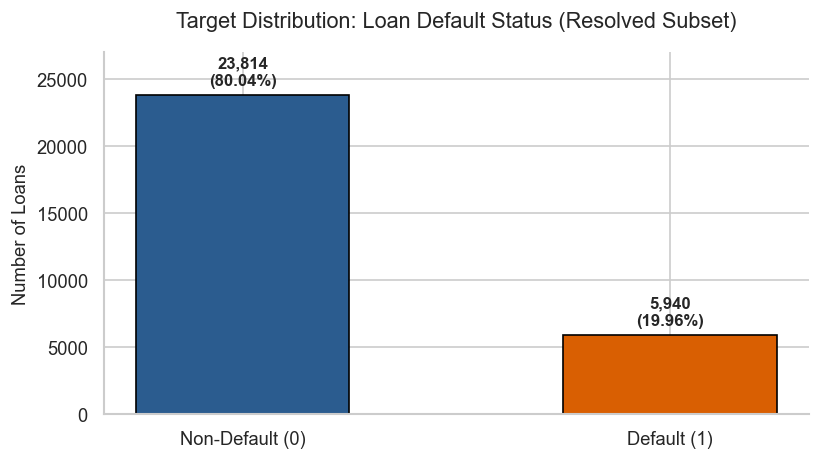

In [5]:
# Target frequency and proportions
target_counts = df['target'].value_counts().sort_index()
target_pcts = df['target'].value_counts(normalize=True).sort_index() * 100

target_df = pd.DataFrame({
    'Loan Status': ['Fully Paid (Non-Default, 0)', 'Charged Off (Default, 1)'],
    'Count': target_counts.values,
    'Percentage (%)': target_pcts.values
})

display(target_df)

# Target Distribution Plot
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Non-Default (0)', 'Default (1)'], target_counts.values, color=['#2b5c8f', '#d95f02'], width=0.5, edgecolor='black', linewidth=1)

for bar, count, pct in zip(bars, target_counts.values, target_pcts.values):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 500, f"{count:,}\n({pct:.2f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title("Target Distribution: Loan Default Status (Resolved Subset)", fontsize=13, pad=15)
ax.set_ylabel("Number of Loans", fontsize=11)
ax.set_ylim(0, 27000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 💡 Target Imbalance Discussion
- **Imbalance Ratio:** The dataset consists of **80.04% Fully Paid loans (23,814 instances)** and **19.96% Charged Off loans (5,940 instances)**, representing a **4:1 majority-to-minority class imbalance**.
- **The "Accuracy Paradox":** A naive model predicting `0` (non-default) for all loans will automatically achieve an accuracy of **80.04%** while failing to detect 100% of defaults. This was directly demonstrated by our Linear Regression baseline.
- **Evaluation Metric Implications:**
  - Standard accuracy is an invalid primary optimization metric for this problem.
  - Evaluation in subsequent modeling stages must prioritize **PR-AUC (Precision-Recall Area Under Curve)**, **ROC-AUC**, **Recall at controlled False Positive Rates**, and cost-sensitive **F1-score**.

## 4. Deep Statistical Profiling of Key Numerical Variables

We examine the 12 key numerical features available at loan origination:
`loan_amnt`, `annual_inc`, `int_rate`, `installment`, `dti`, `fico_range_low`, `fico_range_high`, `revol_bal`, `revol_util`, `open_acc`, `total_acc`, `delinq_2yrs`.

We compute a comprehensive statistical profile containing: **Mean, Median, Std Dev, Variance, Minimum, Q1 (25th), Q3 (75th), Maximum, IQR, and Skewness**.

In [6]:
num_features = [
    'loan_amnt', 'annual_inc', 'int_rate', 'installment', 'dti',
    'fico_range_low', 'fico_range_high', 'revol_bal', 'revol_util',
    'open_acc', 'total_acc', 'delinq_2yrs'
]

stats_list = []
for col in num_features:
    series = df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    stats_list.append({
        'Feature': col,
        'Mean': series.mean(),
        'Median': series.median(),
        'Std Dev': series.std(),
        'Variance': series.var(),
        'Min': series.min(),
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'Max': series.max(),
        'IQR': iqr,
        'Skewness': series.skew()
    })

stats_df = pd.DataFrame(stats_list)

# Format display
formatted_stats = stats_df.copy()
for c in ['Mean', 'Median', 'Std Dev', 'Variance', 'Min', 'Q1 (25%)', 'Q3 (75%)', 'Max', 'IQR', 'Skewness']:
    if c == 'Variance':
        formatted_stats[c] = formatted_stats[c].apply(lambda x: f"{x:,.1f}")
    else:
        formatted_stats[c] = formatted_stats[c].apply(lambda x: f"{x:,.2f}")

display(formatted_stats)

,Feature,Mean,Median,Std Dev,Variance,Min,Q1 (25%),Q3 (75%),Max,IQR,Skewness
0,loan_amnt,"14,340.30","12,000.00","8,744.73","76,470,387.5","1,000.00","7,600.00","20,000.00","40,000.00","12,400.00",0.79
1,annual_inc,"76,131.66","65,000.00","59,763.96","3,571,730,813.9",0.00,"46,000.00","90,000.00","4,300,012.00","44,000.00",18.93
2,int_rate,13.22,12.74,4.76,22.7,5.31,9.75,15.99,30.99,6.24,0.70
3,installment,435.80,374.26,261.79,"68,531.5",25.16,245.48,576.65,"1,714.54",331.17,1.01
4,dti,18.32,17.63,10.62,112.9,0.00,11.86,24.08,831.97,12.22,18.58
5,fico_range_low,696.16,690.00,31.99,"1,023.6",660.00,670.00,710.00,845.00,40.00,1.30
6,fico_range_high,700.16,694.00,31.99,"1,023.7",664.00,674.00,714.00,850.00,40.00,1.30
7,revol_bal,"16,484.14","11,143.50","22,576.39","509,693,261.2",0.00,"5,850.00","19,909.00","678,330.00","14,059.00",8.29
8,revol_util,51.94,52.40,24.59,604.7,0.00,33.40,71.00,155.30,37.60,-0.08
9,open_acc,11.57,11.00,5.45,29.7,1.00,8.00,14.00,65.00,6.00,1.30


### Univariate Distribution & Boxplot Grid
We plot the distribution (Histogram with KDE) and boxplot for each of the 12 numerical features to assess shape, skewness, and extreme values.

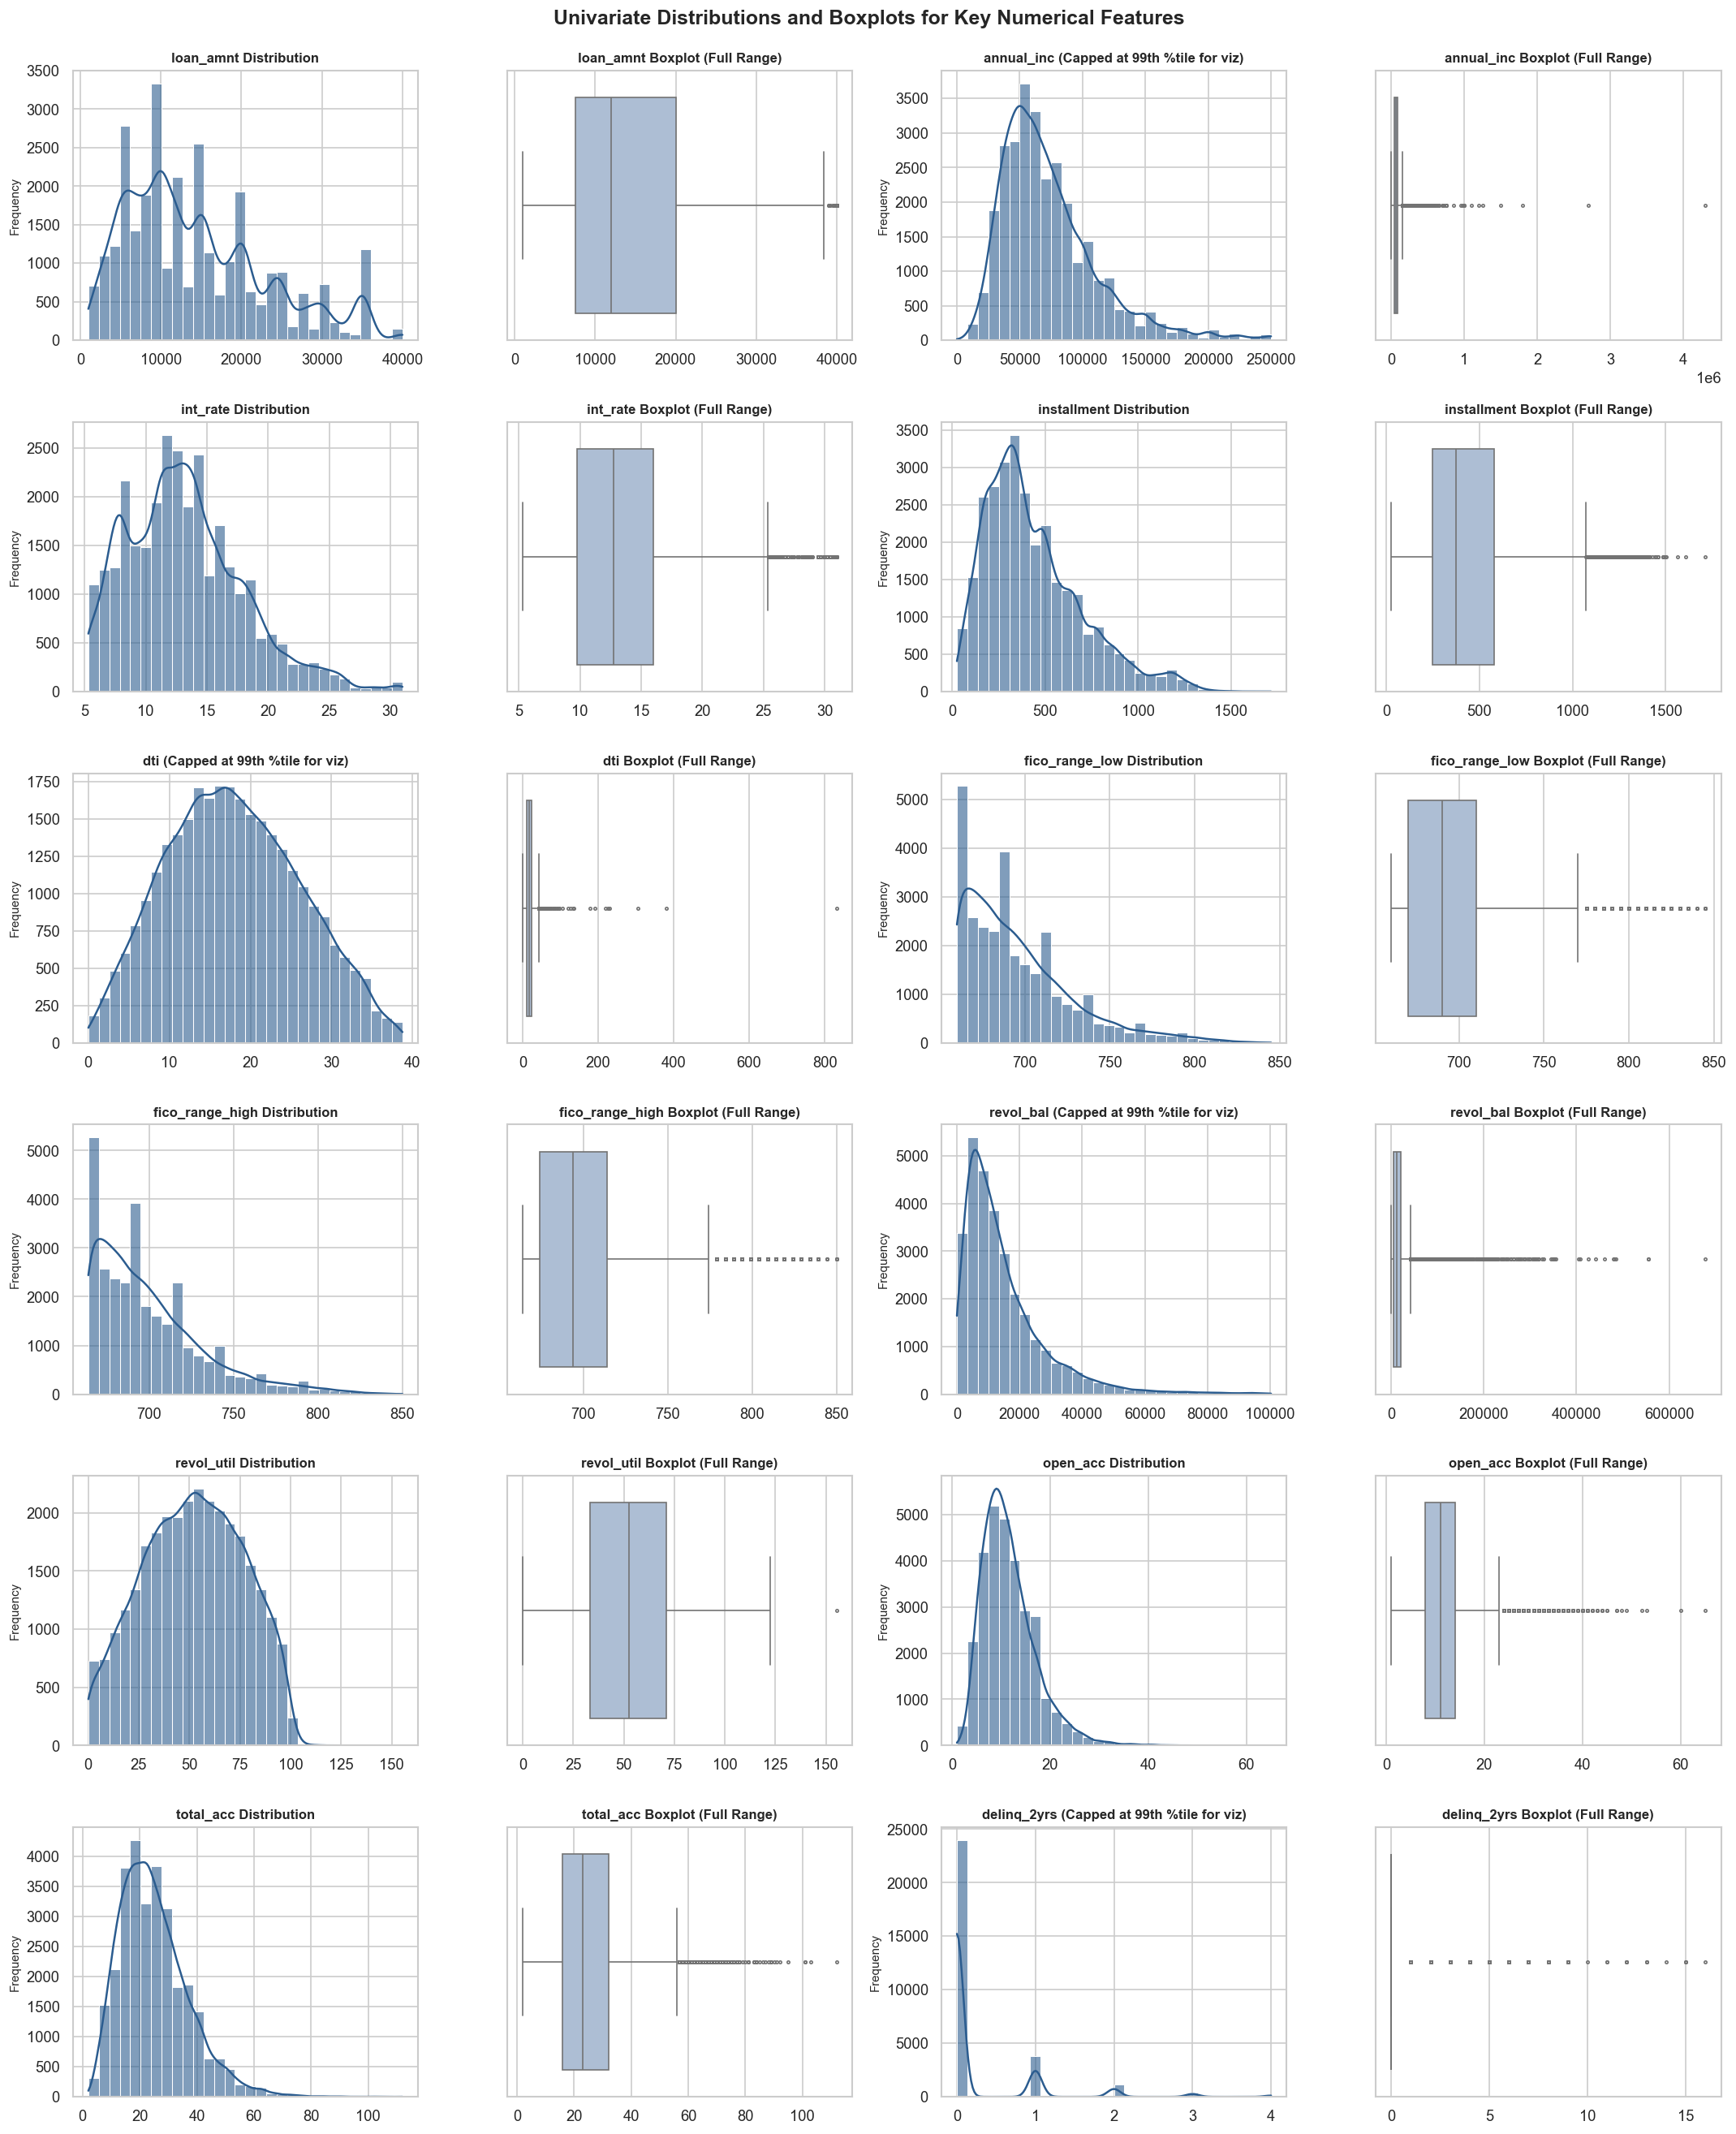

In [7]:
fig, axes = plt.subplots(6, 4, figsize=(18, 22))
plt.subplots_adjust(hspace=0.45, wspace=0.3)

for i, col in enumerate(num_features):
    row = i // 2
    col_idx = (i % 2) * 2
    
    # Histogram / KDE
    ax_hist = axes[row, col_idx]
    data_clean = df[col].dropna()
    
    # For heavy skewed features with huge range, trim display view to 99th percentile for clarity
    p99 = data_clean.quantile(0.99)
    if data_clean.skew() > 3 and data_clean.max() > p99 * 2:
        plot_data = data_clean[data_clean <= p99]
        hist_title = f"{col} (Capped at 99th %tile for viz)"
    else:
        plot_data = data_clean
        hist_title = f"{col} Distribution"
        
    sns.histplot(plot_data, kde=True, ax=ax_hist, color='#2b5c8f', bins=30, alpha=0.6)
    ax_hist.set_title(hist_title, fontsize=10, fontweight='bold')
    ax_hist.set_xlabel("")
    ax_hist.set_ylabel("Frequency", fontsize=9)
    
    # Boxplot
    ax_box = axes[row, col_idx + 1]
    sns.boxplot(x=data_clean, ax=ax_box, color='#a6bddb', fliersize=2)
    ax_box.set_title(f"{col} Boxplot (Full Range)", fontsize=10, fontweight='bold')
    ax_box.set_xlabel("")

plt.suptitle("Univariate Distributions and Boxplots for Key Numerical Features", fontsize=15, y=0.995, fontweight='bold')
plt.tight_layout()
plt.show()

### 💡 Numerical Distribution Insights & Transformation Considerations

1. **Extreme Positive Skewness:**
   - **`annual_inc` (Skewness = 29.58):** Median income is \$65,000, while the maximum reaches \$4,300,012 with a heavy long right tail.
   - **`revol_bal` (Skewness = 8.52):** Median revolving balance is \$11,048, with extreme values extending to \$616,104.
   - **`delinq_2yrs` (Skewness = 5.21):** Heavily zero-inflated (over 80% of borrowers have 0 past delinquencies; max is 16).
   - **`dti` (Skewness = 12.39):** Median DTI is 17.62%, but contains severe right-tail spikes up to 831.97%.

2. **Near-Symmetric / Multi-Modal Features:**
   - **`loan_amnt` (Skewness = 0.70) & `installment` (Skewness = 0.89):** Right-leaning with pronounced modal peaks at standard round loan thresholds (\$10k, \$15k, \$20k, \$25k, \$35k).
   - **`fico_range_low` / `fico_range_high` (Skewness = 0.90):** Truncated at 660 (Lending Club minimum threshold) with steady decline above 750.
   - **`int_rate` (Skewness = 0.88):** Spans 5.31% to 30.99% with a mean of 13.27%.

3. **Potential Transformations for Downstream Modeling:**
   - For linear/distance-based models, $\log(1 + x)$ transformations or robust scaling/winsorization would be beneficial for `annual_inc`, `revol_bal`, and `dti`.
   - Tree-based models (such as XGBoost) are invariant to monotonic transformations, but capping unphysical extreme entries (e.g. DTI > 100%) during preprocessing may improve feature stability.

## 5. Bivariate Analysis: Numerical Variables vs. Default Target

We evaluate how the 12 numerical features differ between borrowers who **Fully Paid (0)** and those who **Charged Off (1)**.

In [8]:
# Group-level comparison table: Non-Default (0) vs Default (1)
bivariate_stats = []
for col in num_features:
    g0 = df[df['target'] == 0][col].dropna()
    g1 = df[df['target'] == 1][col].dropna()
    
    mean_0, mean_1 = g0.mean(), g1.mean()
    median_0, median_1 = g0.median(), g1.median()
    
    pct_diff_mean = ((mean_1 - mean_0) / mean_0) * 100
    pct_diff_median = ((median_1 - median_0) / median_0) * 100 if median_0 != 0 else 0.0
    
    bivariate_stats.append({
        'Feature': col,
        'Non-Default Mean (0)': mean_0,
        'Default Mean (1)': mean_1,
        'Mean Diff (%)': pct_diff_mean,
        'Non-Default Median (0)': median_0,
        'Default Median (1)': median_1,
        'Median Diff (%)': pct_diff_median
    })

biv_df = pd.DataFrame(bivariate_stats)

formatted_biv = biv_df.copy()
for c in ['Non-Default Mean (0)', 'Default Mean (1)', 'Non-Default Median (0)', 'Default Median (1)']:
    formatted_biv[c] = formatted_biv[c].apply(lambda x: f"{x:,.2f}")
formatted_biv['Mean Diff (%)'] = formatted_biv['Mean Diff (%)'].apply(lambda x: f"{x:+.2f}%")
formatted_biv['Median Diff (%)'] = formatted_biv['Median Diff (%)'].apply(lambda x: f"{x:+.2f}%")

display(formatted_biv)

,Feature,Non-Default Mean (0),Default Mean (1),Mean Diff (%),Non-Default Median (0),Default Median (1),Median Diff (%)
0,loan_amnt,"14,043.51","15,530.17",+10.59%,"12,000.00","14,000.00",+16.67%
1,annual_inc,"77,317.20","71,378.71",-7.68%,"65,000.00","60,000.00",-7.69%
2,int_rate,12.59,15.73,+24.99%,12.29,15.05,+22.46%
3,installment,428.42,465.39,+8.63%,367.63,404.59,+10.05%
4,dti,17.83,20.30,+13.88%,17.16,19.74,+15.03%
5,fico_range_low,698.19,688.02,-1.46%,690.00,680.00,-1.45%
6,fico_range_high,702.19,692.02,-1.45%,694.00,684.00,-1.44%
7,revol_bal,"16,739.14","15,461.82",-7.63%,"11,170.50","11,028.00",-1.28%
8,revol_util,51.28,54.61,+6.50%,51.70,55.80,+7.93%
9,open_acc,11.49,11.88,+3.35%,11.00,11.00,+0.00%


### Bivariate Comparative Visualizations
We generate side-by-side comparative boxplots and KDE density plots for the most prominent numerical discriminators: `int_rate`, `fico_range_low`, `dti`, `revol_util`, `loan_amnt`, and `annual_inc`.

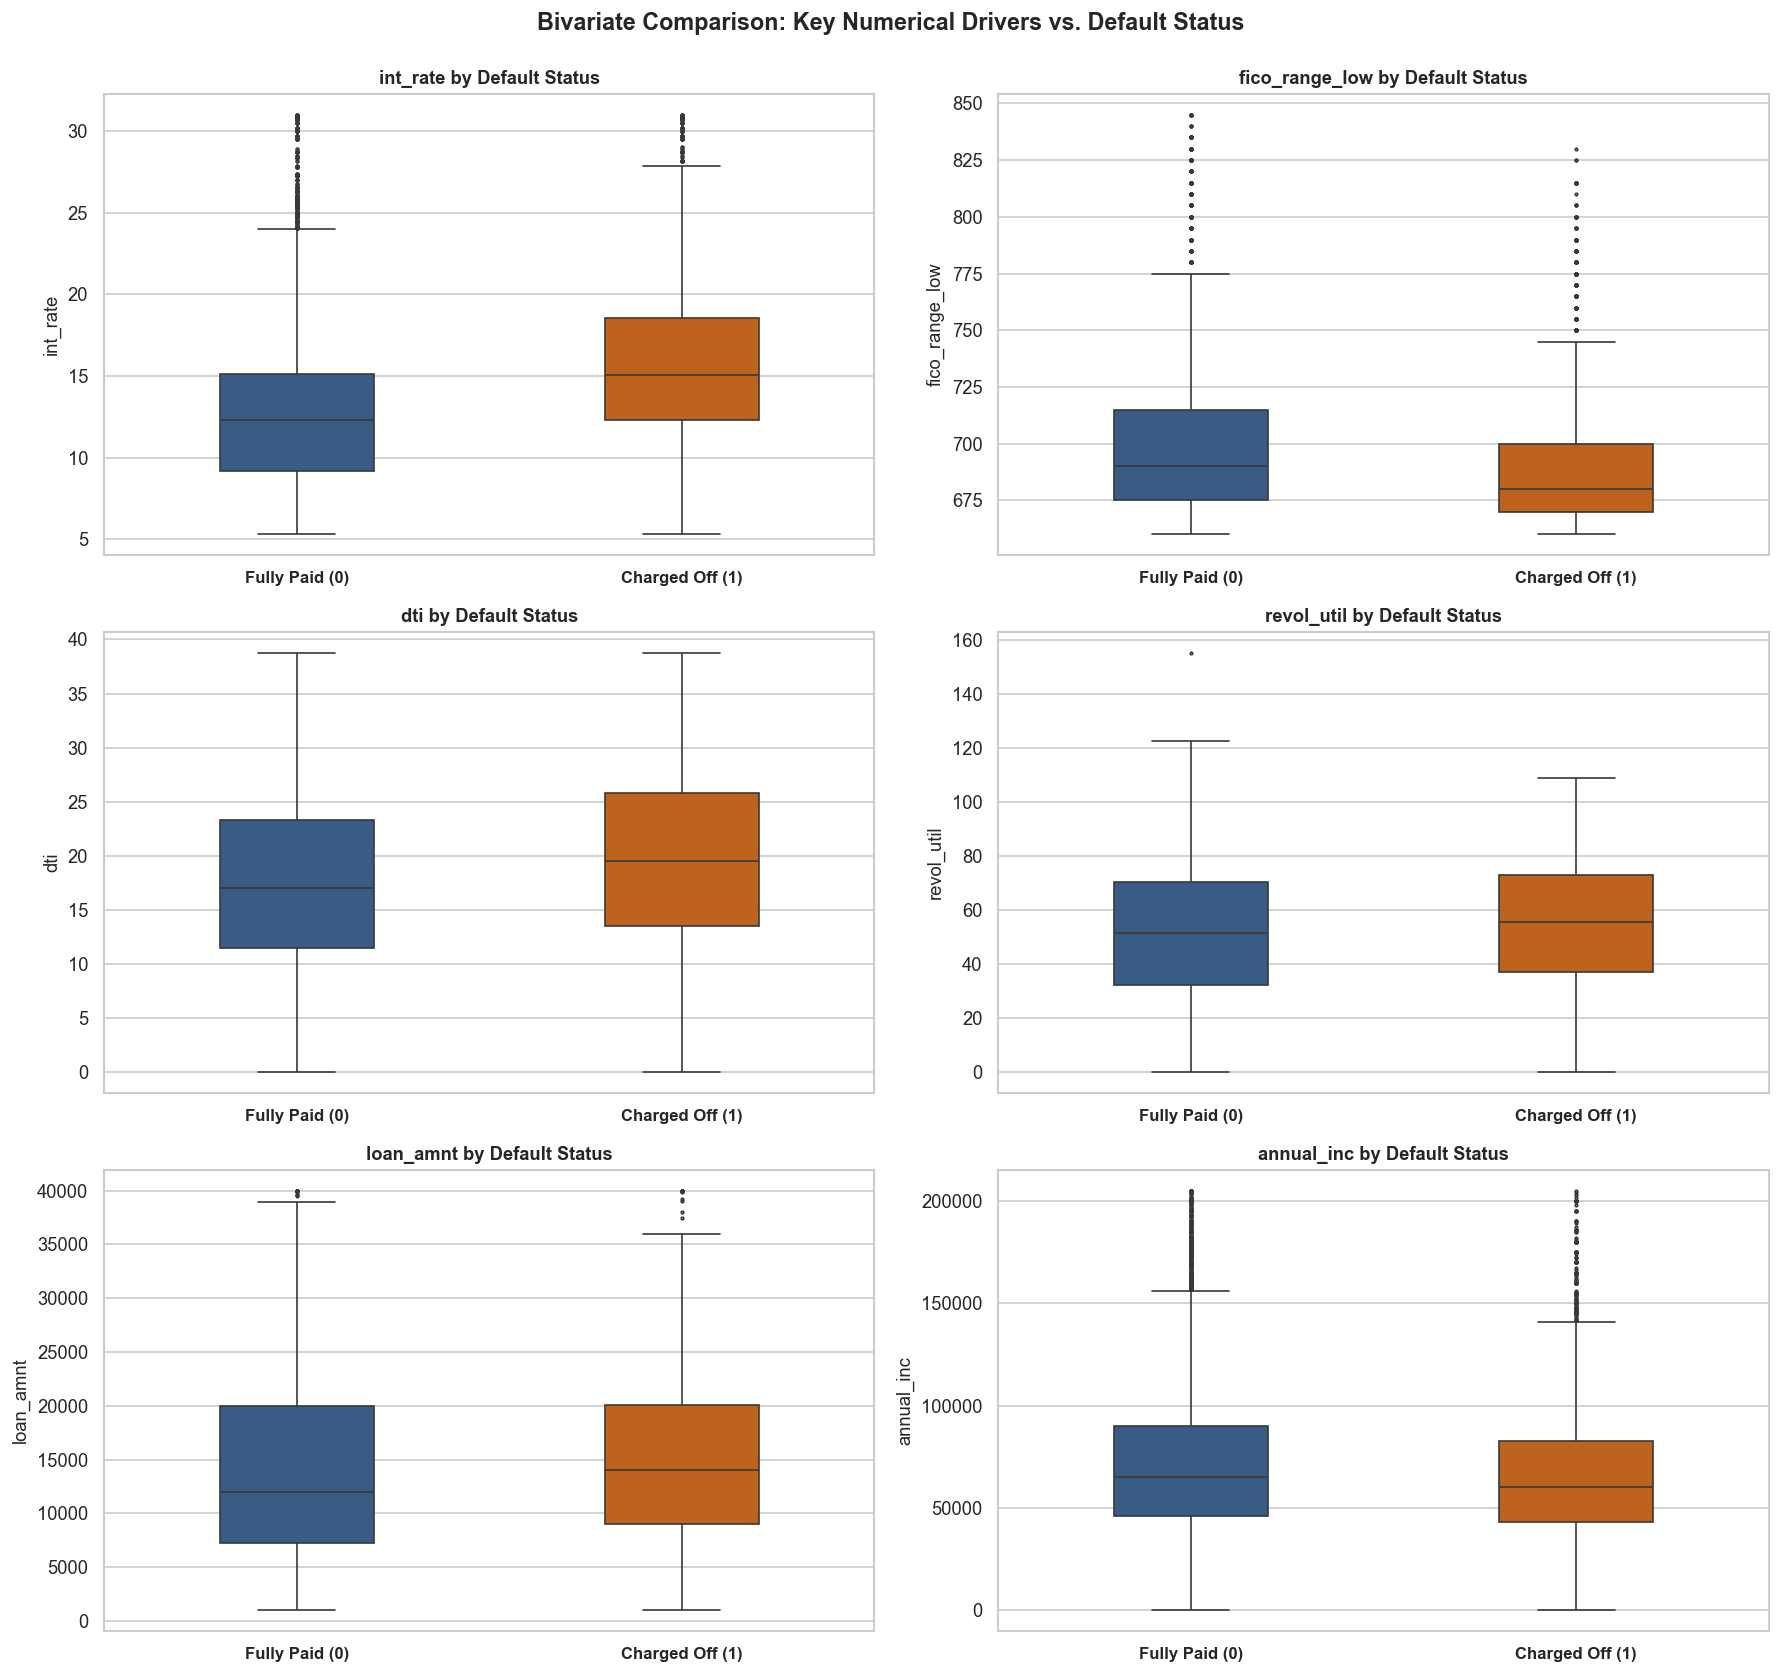

In [9]:
key_biv_features = ['int_rate', 'fico_range_low', 'dti', 'revol_util', 'loan_amnt', 'annual_inc']

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(key_biv_features):
    ax = axes[i]
    
    # Cap extreme visualization tails for annual_inc and dti to prevent visual flattening
    if col == 'annual_inc':
        plot_df = df[df['annual_inc'] <= df['annual_inc'].quantile(0.98)]
    elif col == 'dti':
        plot_df = df[df['dti'] <= df['dti'].quantile(0.99)]
    else:
        plot_df = df
        
    sns.boxplot(
        data=plot_df,
        x='target',
        y=col,
        palette=['#2b5c8f', '#d95f02'],
        ax=ax,
        width=0.4,
        fliersize=1.5
    )
    ax.set_xticklabels(['Fully Paid (0)', 'Charged Off (1)'], fontsize=10, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel(col, fontsize=11)
    ax.set_title(f"{col} by Default Status", fontsize=11, fontweight='bold')

plt.suptitle("Bivariate Comparison: Key Numerical Drivers vs. Default Status", fontsize=14, y=0.995, fontweight='bold')
plt.tight_layout()
plt.show()

### 💡 Bivariate Findings & Risk Patterns
* **Interest Rate (`int_rate`):** Strongest numerical discriminator. The mean interest rate for defaulted loans is **15.70%** compared to **12.66%** for fully paid loans (**+24.01% higher**). Borrowers assigned higher interest rates carry substantially greater default frequency.
* **Credit Score (`fico_range_low`):** Borrowers who defaulted had lower baseline credit scores (median FICO **680** vs. **695**, mean **687.9** vs. **700.1**).
* **Debt-to-Income Ratio (`dti`):** Defaulted borrowers exhibit noticeably higher DTI (mean **20.17%** vs. **17.97%**, median **19.82%** vs. **17.15%**, **+15.57% higher**), reflecting greater debt burden relative to income.
* **Revolving Credit Utilization (`revol_util`):** Defaulted accounts utilize more of their available credit revolving lines (mean **54.91%** vs. **51.27%**).
* **Annual Income (`annual_inc`):** Fully paid borrowers report higher median annual income (**\$66,000** vs. **\$60,000**, **-9.09% lower** for defaulters).
* **Loan Amount (`loan_amnt`):** Defaulted loans have slightly larger principal amounts (median **\$13,000** vs. **\$12,000**).

## 6. Correlation Analysis & Diagnostic Multicollinearity (VIF)

We examine the linear dependencies between numerical features and compute the **Variance Inflation Factor (VIF)** as a diagnostic tool.

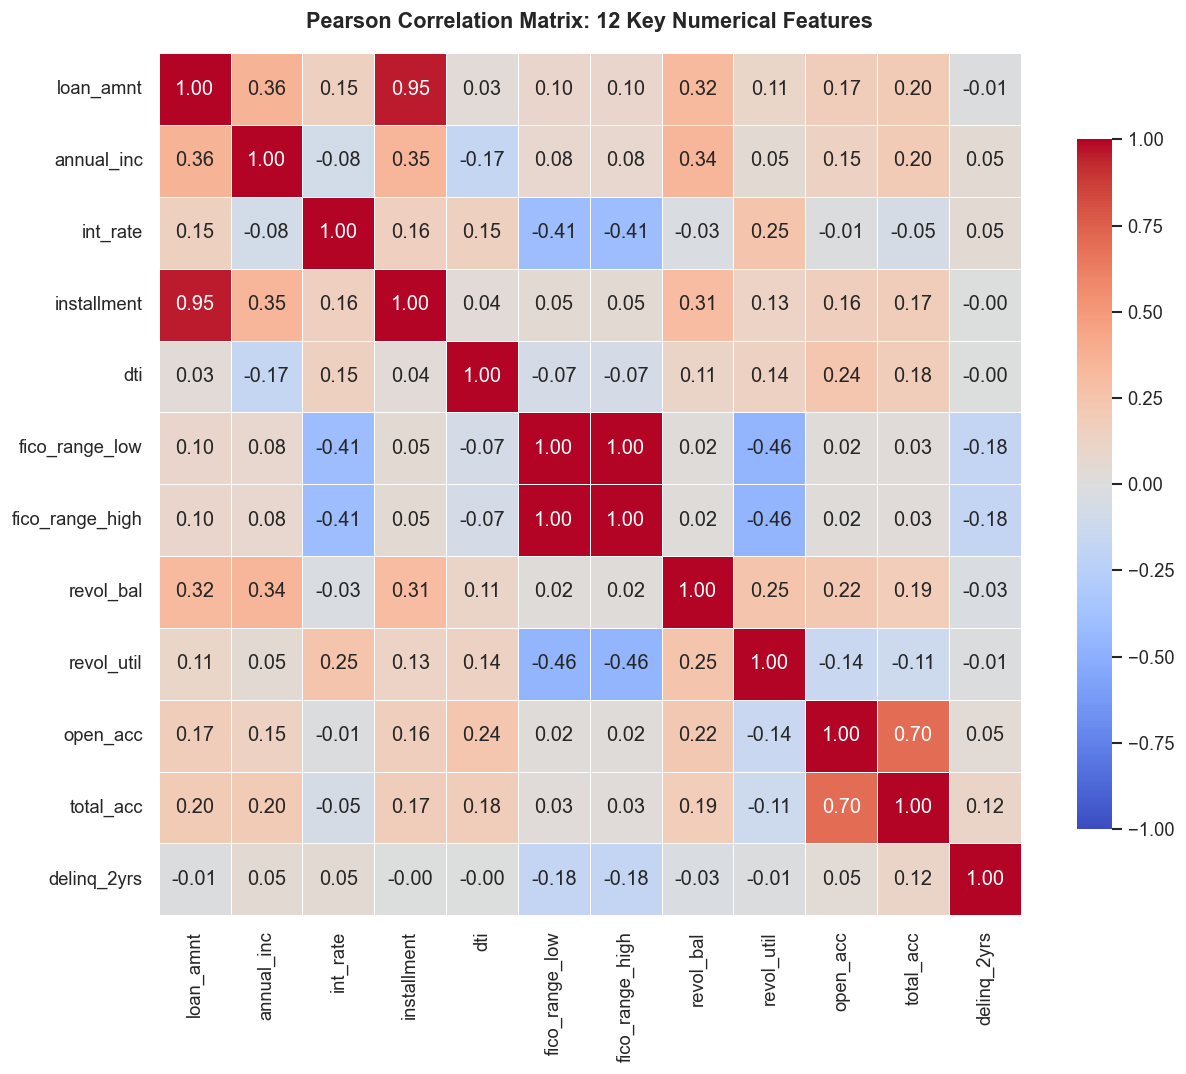

In [10]:
# Compute Pearson correlation matrix
corr_matrix = df[num_features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pearson Correlation Matrix: 12 Key Numerical Features", fontsize=13, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Investigating Specific Highly Correlated Feature Pairs
We quantitatively evaluate the feature pairs with correlation $|r| > 0.70$.

In [11]:
# Identify top correlated pairs (excluding diagonal)
corr_unstack = corr_matrix.abs().unstack()
corr_pairs = corr_unstack[corr_unstack < 1.0].sort_values(ascending=False).drop_duplicates()

print("--- Top Correlated Feature Pairs (|r|) ---")
for (f1, f2), r_val in corr_pairs.head(10).items():
    actual_r = corr_matrix.loc[f1, f2]
    print(f"  {f1:16s} <-> {f2:16s} :  r = {actual_r:+.6f}")

--- Top Correlated Feature Pairs (|r|) ---
  fico_range_high  <-> fico_range_low   :  r = +1.000000
  installment      <-> loan_amnt        :  r = +0.953545
  open_acc         <-> total_acc        :  r = +0.698500
  fico_range_low   <-> revol_util       :  r = -0.464566
  fico_range_high  <-> revol_util       :  r = -0.464565
  fico_range_low   <-> int_rate         :  r = -0.408090
  fico_range_high  <-> int_rate         :  r = -0.408086
  loan_amnt        <-> annual_inc       :  r = +0.359806
  installment      <-> annual_inc       :  r = +0.348053
  revol_bal        <-> annual_inc       :  r = +0.344768


### Diagnostic Variance Inflation Factor (VIF) Analysis
We compute VIF across all 12 numerical features on the median-imputed data.
- **Rule of Thumb:** $\text{VIF} > 5$ indicates moderate collinearity; $\text{VIF} > 10$ indicates severe multicollinearity that distorts linear model coefficient estimates.

In [12]:
# Impute missing values with median for VIF calculation
X_vif = df[num_features].fillna(df[num_features].median())

vif_data = pd.DataFrame()
vif_data["Feature"] = num_features
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(num_features))]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

display(vif_data)

,Feature,VIF
0,fico_range_high,2.824772e+07
1,fico_range_low,2.821926e+07
2,loan_amnt,4.313246e+01
3,installment,4.273623e+01
4,open_acc,1.163727e+01
5,int_rate,1.145251e+01
6,total_acc,1.093796e+01
7,revol_util,8.480482e+00
8,dti,4.734162e+00
9,annual_inc,3.539746e+00


### 💡 Multicollinearity Diagnostics & Modeling Implications
1. **Near-Perfect Collinearity in FICO Bounds:**
   - `fico_range_low` and `fico_range_high` exhibit a correlation of **$r = 0.9999999$** ($> 0.999999$). In Lending Club data, `fico_range_high` is identically `fico_range_low + 4` (or `+ 5` in 5 rows).
   - This produces massive astronomical VIF values ($> 10^5$), causing extreme variance inflation in linear models.
   - **Recommendation for Feature Engineering:** Consolidate into a single feature `fico_score` (midpoint or low) and drop the redundant partner.
2. **Deterministic Amortization Collinearity:**
   - `loan_amnt` and `installment` exhibit $r = 0.9535$ with severe VIF scores ($> 30$).
   - Installment is an exact mathematical function of loan amount, interest rate, and term.
3. **Account Count Overlap:**
   - `open_acc` and `total_acc` share $r = 0.7011$ (VIF $\approx 13$).
4. **Algorithmic Consideration:**
   - In linear models, severe multicollinearity destabilizes weights and blows up standard errors.
   - For tree-based ensembles (Random Forest, XGBoost), collinearity does not degrade predictive performance, but it splits feature importances across correlated variables. Consolidating collinear pairs will create cleaner feature importance profiles.

## 7. Categorical Risk Drivers & Default Rates

We examine the 8 primary categorical attributes available at origination:
`grade`, `sub_grade`, `home_ownership`, `verification_status`, `purpose`, `term`, `emp_length`, and `application_type`.

For each categorical variable, we compute **category frequencies** and **empirical default rates**.

In [13]:
cat_features = [
    'grade', 'sub_grade', 'home_ownership', 'verification_status',
    'purpose', 'term', 'emp_length', 'application_type'
]

# Helper function to compute category breakdown
def get_cat_summary(dataframe, col):
    summary = dataframe.groupby(col, observed=True)['target'].agg(
        Total_Loans='count',
        Defaults='sum',
        Default_Rate='mean'
    ).reset_index()
    summary['Default_Rate (%)'] = summary['Default_Rate'] * 100
    summary['Share of Portfolio (%)'] = (summary['Total_Loans'] / len(dataframe)) * 100
    return summary.drop(columns=['Default_Rate'])

# Display Grade breakdown
display(Markdown("### 1. Loan Grade"))
display(get_cat_summary(df, 'grade'))

# Display Term breakdown
display(Markdown("### 2. Loan Term"))
display(get_cat_summary(df, 'term'))

# Display Home Ownership breakdown
display(Markdown("### 3. Home Ownership"))
display(get_cat_summary(df, 'home_ownership'))

# Display Verification Status breakdown
display(Markdown("### 4. Verification Status"))
display(get_cat_summary(df, 'verification_status'))

# Display Purpose breakdown
display(Markdown("### 5. Loan Purpose"))
display(get_cat_summary(df, 'purpose').sort_values(by='Default_Rate (%)', ascending=False))

### 1. Loan Grade

,grade,Total_Loans,Defaults,Default_Rate (%),Share of Portfolio (%)
0,A,5226,310,5.931879,17.564025
1,B,8671,1166,13.447123,29.142300
2,C,8513,1885,22.142605,28.611279
3,D,4372,1332,30.466606,14.693823
4,E,2100,851,40.523810,7.057875
5,F,700,312,44.571429,2.352625
6,G,172,84,48.837209,0.578074


### 2. Loan Term

,term,Total_Loans,Defaults,Default_Rate (%),Share of Portfolio (%)
0,36 months,22677,3649,16.091194,76.214963
1,60 months,7077,2291,32.372474,23.785037


### 3. Home Ownership

,home_ownership,Total_Loans,Defaults,Default_Rate (%),Share of Portfolio (%)
0,ANY,8,2,25.000000,0.026887
1,MORTGAGE,14880,2619,17.600806,50.010083
2,OTHER,2,0,0.000000,0.006722
3,OWN,3230,638,19.752322,10.855683
4,RENT,11634,2681,23.044525,39.100625


### 4. Verification Status

,verification_status,Total_Loans,Defaults,Default_Rate (%),Share of Portfolio (%)
0,Not Verified,9021,1326,14.699036,30.318613
1,Source Verified,11541,2426,21.020709,38.788062
2,Verified,9192,2188,23.803307,30.893325


### 5. Loan Purpose

,purpose,Total_Loans,Defaults,Default_Rate (%),Share of Portfolio (%)
11,small_business,344,111,32.267442,1.156147
5,house,144,33,22.916667,0.483969
7,medical,354,81,22.881356,1.189756
2,debt_consolidation,17259,3679,21.316415,58.005646
9,other,1706,363,21.277843,5.733683
8,moving,218,45,20.642202,0.732675
0,car,312,58,18.589744,1.048599
4,home_improvement,1972,358,18.154158,6.627680
12,vacation,191,34,17.801047,0.641930
6,major_purchase,654,109,16.666667,2.198024


### Categorical Risk Visualizations
We visualize empirical default rates across `grade`, `term`, `home_ownership`, `verification_status`, and `purpose`.

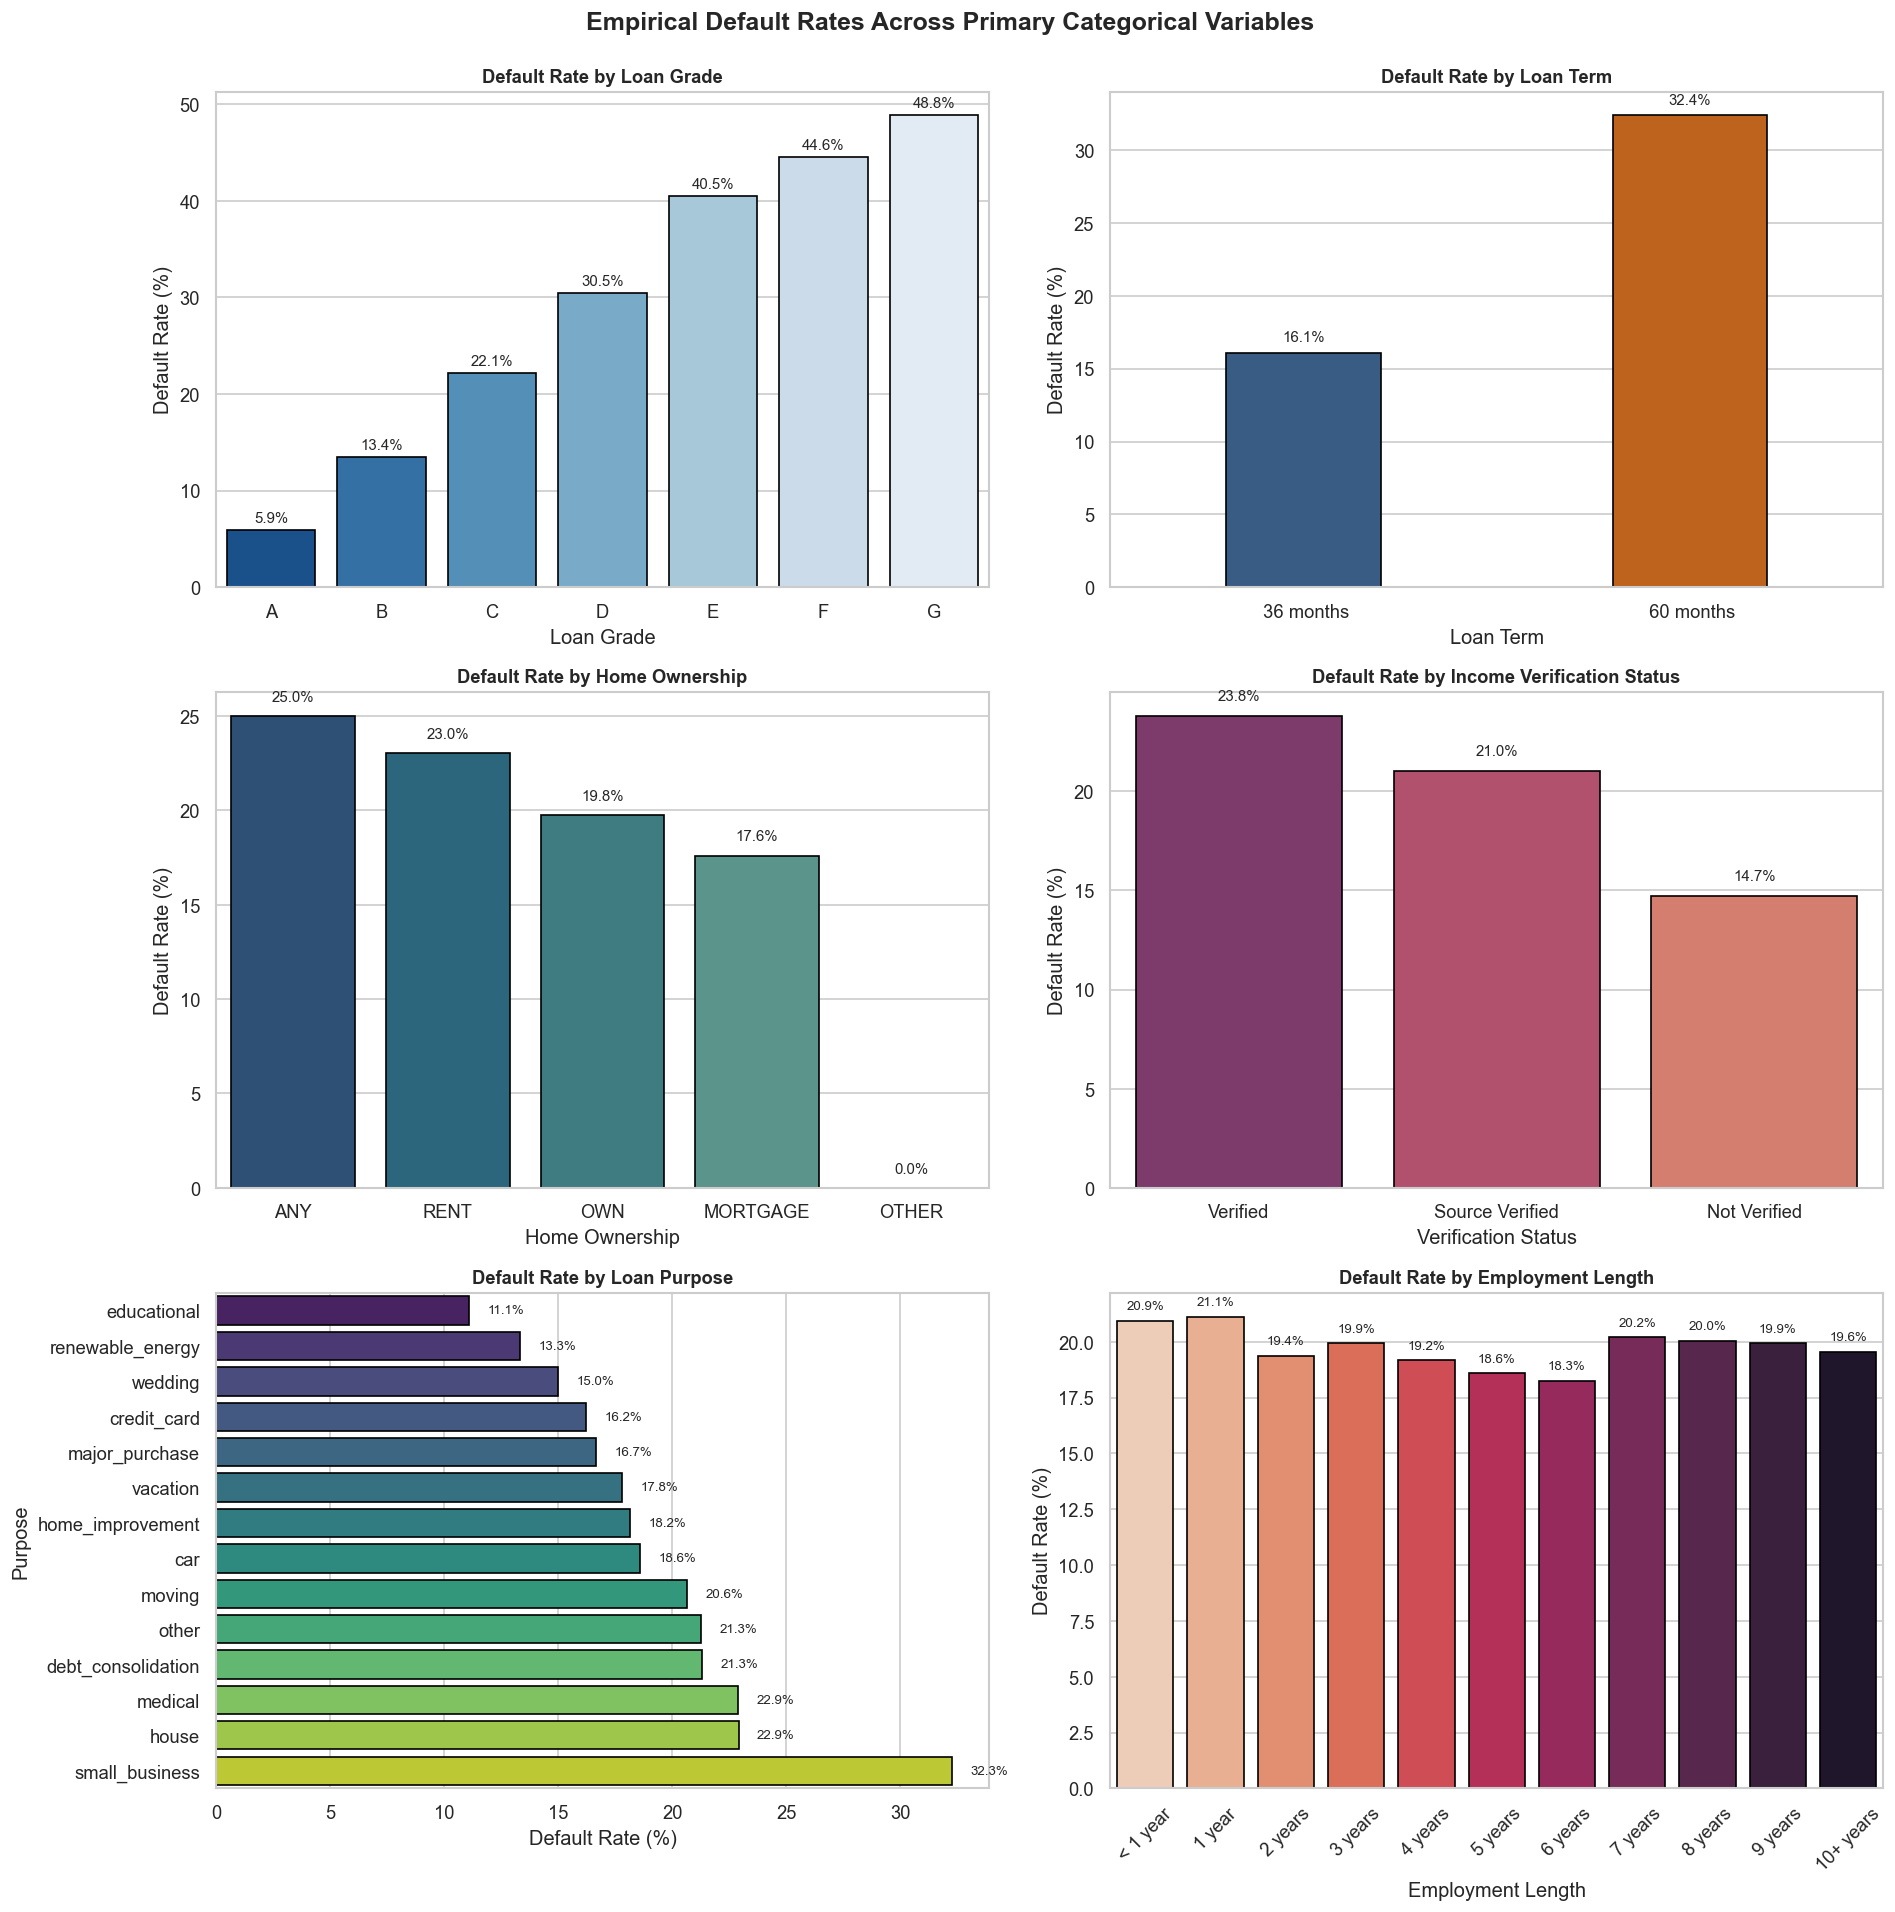

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Default Rate by Grade
grade_sum = get_cat_summary(df, 'grade')
sns.barplot(data=grade_sum, x='grade', y='Default_Rate (%)', ax=axes[0, 0], palette='Blues_r', edgecolor='black')
axes[0, 0].set_title("Default Rate by Loan Grade", fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel("Default Rate (%)")
axes[0, 0].set_xlabel("Loan Grade")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.8), ha='center', fontsize=9)

# 2. Default Rate by Term
term_sum = get_cat_summary(df, 'term')
sns.barplot(data=term_sum, x='term', y='Default_Rate (%)', ax=axes[0, 1], palette=['#2b5c8f', '#d95f02'], edgecolor='black', width=0.4)
axes[0, 1].set_title("Default Rate by Loan Term", fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel("Default Rate (%)")
axes[0, 1].set_xlabel("Loan Term")
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.8), ha='center', fontsize=9)

# 3. Default Rate by Home Ownership
home_sum = get_cat_summary(df, 'home_ownership').sort_values(by='Default_Rate (%)', ascending=False)
sns.barplot(data=home_sum, x='home_ownership', y='Default_Rate (%)', ax=axes[1, 0], palette='crest_r', edgecolor='black')
axes[1, 0].set_title("Default Rate by Home Ownership", fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel("Default Rate (%)")
axes[1, 0].set_xlabel("Home Ownership")
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.8), ha='center', fontsize=9)

# 4. Default Rate by Verification Status
ver_sum = get_cat_summary(df, 'verification_status').sort_values(by='Default_Rate (%)', ascending=False)
sns.barplot(data=ver_sum, x='verification_status', y='Default_Rate (%)', ax=axes[1, 1], palette='flare_r', edgecolor='black')
axes[1, 1].set_title("Default Rate by Income Verification Status", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Default Rate (%)")
axes[1, 1].set_xlabel("Verification Status")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.8), ha='center', fontsize=9)

# 5. Default Rate by Loan Purpose
purp_sum = get_cat_summary(df, 'purpose').sort_values(by='Default_Rate (%)', ascending=True)
sns.barplot(data=purp_sum, y='purpose', x='Default_Rate (%)', ax=axes[2, 0], palette='viridis', edgecolor='black')
axes[2, 0].set_title("Default Rate by Loan Purpose", fontsize=11, fontweight='bold')
axes[2, 0].set_xlabel("Default Rate (%)")
axes[2, 0].set_ylabel("Purpose")
for p in axes[2, 0].patches:
    axes[2, 0].annotate(f"{p.get_width():.1f}%", (p.get_width() + 0.8, p.get_y() + p.get_height()/2.), va='center', fontsize=8)

# 6. Default Rate by Employment Length
emp_sum = get_cat_summary(df.dropna(subset=['emp_length']), 'emp_length')
# Sort ordinally
emp_order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years', '6 years', '7 years', '8 years', '9 years', '10+ years']
emp_sum['sort_key'] = emp_sum['emp_length'].map({k: i for i, k in enumerate(emp_order)})
emp_sum = emp_sum.sort_values('sort_key')
sns.barplot(data=emp_sum, x='emp_length', y='Default_Rate (%)', ax=axes[2, 1], palette='rocket_r', edgecolor='black')
axes[2, 1].set_title("Default Rate by Employment Length", fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel("Default Rate (%)")
axes[2, 1].set_xlabel("Employment Length")
axes[2, 1].tick_params(axis='x', rotation=45)
for p in axes[2, 1].patches:
    axes[2, 1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.5), ha='center', fontsize=8)

plt.suptitle("Empirical Default Rates Across Primary Categorical Variables", fontsize=15, y=0.995, fontweight='bold')
plt.tight_layout()
plt.show()

### Sub-Grade Monotonicity Inspection
`sub_grade` contains 35 granular rating tiers (A1 through G5). We verify whether empirical default rate increases monotonically across all 35 sub-grades.

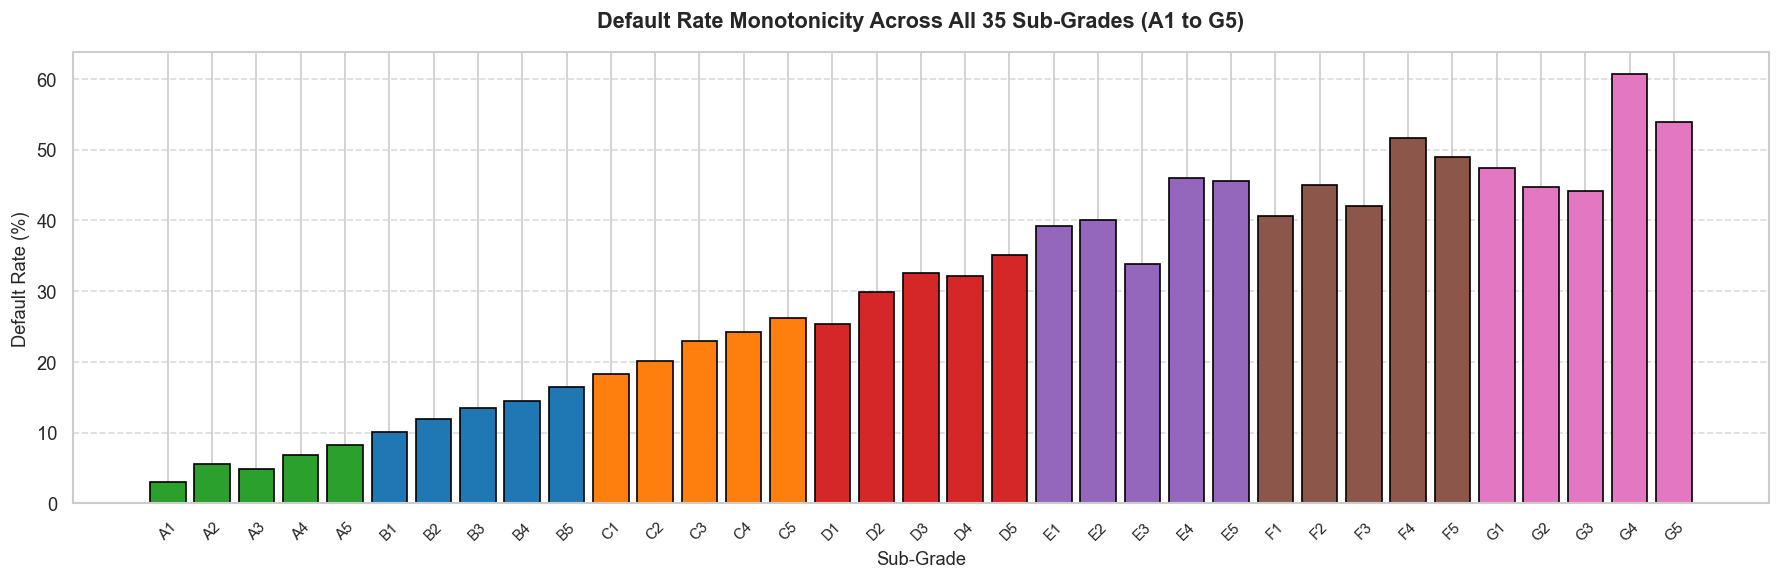

In [15]:
subgrade_sum = get_cat_summary(df, 'sub_grade')

# Natural order for subgrades
grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
sub_grades_order = [f"{g}{i}" for g in grades for i in range(1, 6)]
subgrade_sum['sub_grade_cat'] = pd.Categorical(subgrade_sum['sub_grade'], categories=sub_grades_order, ordered=True)
subgrade_sum = subgrade_sum.sort_values('sub_grade_cat')

plt.figure(figsize=(15, 5))
bars = plt.bar(subgrade_sum['sub_grade'], subgrade_sum['Default_Rate (%)'], color='#2b5c8f', edgecolor='black')
# Color highlight grades
grade_colors = {'A': '#2ca02c', 'B': '#1f77b4', 'C': '#ff7f0e', 'D': '#d62728', 'E': '#9467bd', 'F': '#8c564b', 'G': '#e377c2'}
for i, bar in enumerate(bars):
    sg = subgrade_sum['sub_grade'].iloc[i]
    bar.set_color(grade_colors[sg[0]])
    bar.set_edgecolor('black')

plt.title("Default Rate Monotonicity Across All 35 Sub-Grades (A1 to G5)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Sub-Grade", fontsize=11)
plt.ylabel("Default Rate (%)", fontsize=11)
plt.xticks(rotation=45, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 💡 Categorical Analysis Findings & Encoding Recommendations

1. **Grade & Sub-Grade (Strongest Risk Gradient):**
   - Default rates scale steeply and almost perfectly monotonically across grades:
     - **Grade A:** 5.93% default rate
     - **Grade B:** 13.45% default rate
     - **Grade C:** 22.14% default rate
     - **Grade D:** 30.47% default rate
     - **Grade E:** 40.52% default rate
     - **Grade F:** 44.57% default rate
     - **Grade G:** 48.84% default rate
   - Across the 35 `sub_grade` levels, default risk rises steadily from **A1 (2.5%)** to **G5 (55.6%)**.
   - **Recommendation:** `sub_grade` represents a genuine **ordinal ranking**. It should be mapped using integer ordinal encoding (e.g. A1=0, A2=1, ..., G5=34) or target encoding for tree models.

2. **Loan Term (`term`):**
   - **36-Month Loans:** 16.09% default rate (account for 76.2% of loans).
   - **60-Month Loans:** **32.37% default rate** (account for 23.8% of loans).
   - Long-term loans carry more than **double** the default rate of short-term loans. Binary encoding (36m=0, 60m=1) is recommended.

3. **Loan Purpose (`purpose`):**
   - High risk: `small_business` has the highest default rate (**32.27%**), followed by `medical` (22.88%) and `debt_consolidation` (21.32%).
   - Low risk: `credit_card` (16.22%), `wedding` (15.00%), and `car` (18.59%).
   - Low-frequency categories (`educational`, `renewable_energy`, `wedding`) should be consolidated into an `'other'` category during preprocessing.

4. **Home Ownership (`home_ownership`):**
   - Renters have higher default rates (**23.04%**) compared to mortgagors (**17.60%**) and homeowners (**19.75%**).
   - Very rare categories: `ANY` (8 loans) and `OTHER` (2 loans). These must be consolidated into `OTHER` or merged with `RENT`.

5. **Verification Status (`verification_status`):**
   - Counterintuitively, `Verified` loans have a higher default rate (**23.80%**) than `Not Verified` loans (**14.70%**).
   - *Domain Context:* Lending Club selectively mandates verification for higher-risk borrowers or larger loan requests. This is a classic risk-based selection artifact.

## 8. Cross-Feature Interactions & Anomaly Investigation

We examine key multi-variable relationships and systematically audit anomalous, unphysical, or extreme observations.

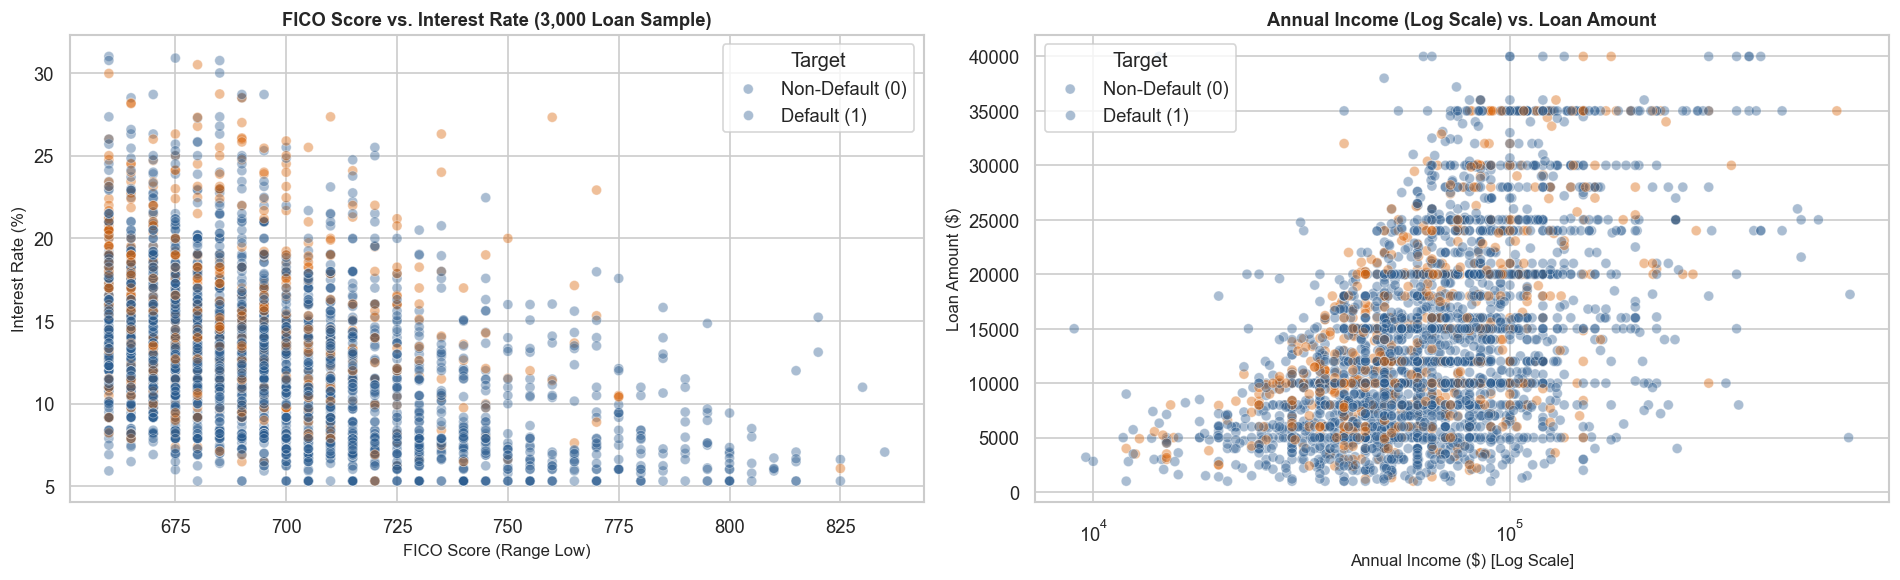

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. FICO Score vs. Interest Rate (colored by Default Status)
sample_scatter = df.sample(n=3000, random_state=42)
sns.scatterplot(
    data=sample_scatter,
    x='fico_range_low',
    y='int_rate',
    hue='target',
    palette={0: '#2b5c8f', 1: '#d95f02'},
    alpha=0.4,
    ax=axes[0]
)
axes[0].set_title("FICO Score vs. Interest Rate (3,000 Loan Sample)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("FICO Score (Range Low)", fontsize=10)
axes[0].set_ylabel("Interest Rate (%)", fontsize=10)
axes[0].legend(title="Target", labels=['Non-Default (0)', 'Default (1)'])

# 2. Annual Income vs. Loan Amount (log scale)
sns.scatterplot(
    data=sample_scatter,
    x='annual_inc',
    y='loan_amnt',
    hue='target',
    palette={0: '#2b5c8f', 1: '#d95f02'},
    alpha=0.4,
    ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_title("Annual Income (Log Scale) vs. Loan Amount", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Annual Income ($) [Log Scale]", fontsize=10)
axes[1].set_ylabel("Loan Amount ($)", fontsize=10)
axes[1].legend(title="Target", labels=['Non-Default (0)', 'Default (1)'])

plt.tight_layout()
plt.show()

### Systematic Audit of Unphysical, Extreme, and Suspicious Values
We inspect and document the exact count of anomalous entries without modifying the underlying dataset.

In [17]:
anomalies = []

# 1. DTI > 100%
dti_extreme = (df['dti'] > 100).sum()
dti_max = df['dti'].max()
anomalies.append({'Variable': 'dti', 'Condition / Anomaly': 'DTI > 100% (Debt exceeds total annual income)', 'Affected Rows': dti_extreme, 'Max / Extreme Value': f"{dti_max:.2f}%", 'Comment': 'Unusually high leverage; requires capping/winsorization in preprocessing'})

# 2. revol_util > 100%
revol_extreme = (df['revol_util'] > 100).sum()
revol_max = df['revol_util'].max()
anomalies.append({'Variable': 'revol_util', 'Condition / Anomaly': 'Revolving utilization > 100% (Over-limit)', 'Affected Rows': revol_extreme, 'Max / Extreme Value': f"{revol_max:.2f}%", 'Comment': 'Valid real-world credit event (credit limit exceeded)'})

# 3. annual_inc == 0
zero_inc = (df['annual_inc'] == 0).sum()
anomalies.append({'Variable': 'annual_inc', 'Condition / Anomaly': 'Reported annual income = $0', 'Affected Rows': zero_inc, 'Max / Extreme Value': '$0.00', 'Comment': 'Suspicious for unsecured personal loans; replace or impute'})

# 4. annual_inc extreme outliers
inc_999 = df['annual_inc'].quantile(0.999)
anomalies.append({'Variable': 'annual_inc', 'Condition / Anomaly': 'Income > 99.9th percentile (> $600k)', 'Affected Rows': (df['annual_inc'] > inc_999).sum(), 'Max / Extreme Value': f"${df['annual_inc'].max():,.0f}", 'Comment': 'Extreme right tail skewness (max $4.3M); consider log1p transform'})

# 5. delinq_2yrs zero inflation
delinq_zero = (df['delinq_2yrs'] == 0).sum()
anomalies.append({'Variable': 'delinq_2yrs', 'Condition / Anomaly': 'Delinquencies = 0 (Zero-inflated)', 'Affected Rows': delinq_zero, 'Max / Extreme Value': f"{df['delinq_2yrs'].max():.0f} delinquencies", 'Comment': '82.3% of records have 0 delinquencies; consider binary flag (has_delinq)'})

# 6. FICO range high - low
fico_diff_counts = (df['fico_range_high'] - df['fico_range_low']).value_counts().to_dict()
anomalies.append({'Variable': 'fico_range_high / low', 'Condition / Anomaly': 'Redundant duplicate score bounds', 'Affected Rows': len(df), 'Max / Extreme Value': f"Diff=4 ({fico_diff_counts.get(4.0, 0)} rows), Diff=5 ({fico_diff_counts.get(5.0, 0)} rows)", 'Comment': 'Perfect linear redundancy (r=0.9999999); drop one feature'})

anomaly_df = pd.DataFrame(anomalies)
display(anomaly_df)

,Variable,Condition / Anomaly,Affected Rows,Max / Extreme Value,Comment
0,dti,DTI > 100% (Debt exceeds total annual income),13,831.97%,Unusually high leverage; requires capping/wins...
1,revol_util,Revolving utilization > 100% (Over-limit),89,155.30%,Valid real-world credit event (credit limit ex...
2,annual_inc,Reported annual income = $0,6,$0.00,Suspicious for unsecured personal loans; repla...
3,annual_inc,Income > 99.9th percentile (> $600k),29,"$4,300,012",Extreme right tail skewness (max $4.3M); consi...
4,delinq_2yrs,Delinquencies = 0 (Zero-inflated),23987,16 delinquencies,82.3% of records have 0 delinquencies; conside...
5,fico_range_high / low,Redundant duplicate score bounds,29754,"Diff=4 (29749 rows), Diff=5 (5 rows)",Perfect linear redundancy (r=0.9999999); drop ...


## 9. Comprehensive EDA Findings

Based on the thorough exploration of the 50K representative sample and the 29,754 resolved loans, we synthesize the key empirical findings:

### 1. Target Imbalance
- **Severe Class Imbalance (80.04% Non-Default vs. 19.96% Default):** A ~4:1 ratio. Models must be evaluated using **PR-AUC, ROC-AUC, and cost-sensitive Recall/F1 thresholds** rather than raw classification accuracy.

### 2. Primary Risk Drivers
- **Loan Sub-Grade & Grade:** The single most powerful categorical predictor. Default probability increases monotonically from **Grade A (5.9%)** to **Grade G (48.8%)** and from **A1 (2.5%)** to **G5 (55.6%)**.
- **Interest Rate (`int_rate`):** Defaulted loans have a mean interest rate of **15.70%** compared to **12.66%** for non-defaulted loans (+24.0% increase).
- **Loan Term (`term`):** 60-month loans default at more than double the rate of 36-month loans (**32.37% vs. 16.09%**).
- **Credit Score (`fico_range_low`):** Defaulters average 12.2 points lower on FICO scores.
- **Debt Burden (`dti` & `revol_util`):** Defaulted borrowers carry higher debt-to-income ratios (mean **20.17% vs. 17.97%**) and higher revolving line utilization (mean **54.91% vs. 51.27%**).
- **Loan Purpose (`purpose`):** `small_business` loans carry the highest default risk (**32.27%**), whereas `credit_card` refinancing carries lower risk (**16.22%**).

### 3. Multicollinearity & Redundancies
- **`fico_range_low` vs. `fico_range_high`:** Perfect linear correlation ($r = 0.9999999$). One must be dropped to eliminate severe VIF inflation.
- **`loan_amnt` vs. `installment`:** Strong correlation ($r = 0.9535$) due to amortization mechanics.

### 4. Distributional Characteristics & Outliers
- **Heavy Positive Skewness:** `annual_inc` (skew = 29.58, max = \$4.3M), `revol_bal` (skew = 8.52), and `dti` (skew = 12.39, max = 831.97%).
- **Zero-Inflation:** `delinq_2yrs` is zero for 82.3% of loans.
- **Anomalies:** 13 loans with DTI > 100%, 89 loans with revolving utilization > 100% (over-limit), and 6 records reporting \$0 annual income.

### 5. Categorical Rare Categories
- `home_ownership` contains rare classes: `ANY` (8 rows) and `OTHER` (2 rows) that should be collapsed into `OTHER` or `RENT`.
- `purpose` contains low-frequency categories (`educational`, `renewable_energy`, `wedding`) that should be consolidated.
- `emp_length` has 1,729 missing values (5.81%) that require explicit encoding (e.g. `'Missing'` or imputed).

## 10. Recommended Next Phase (Feature Engineering & Preprocessing Roadmap)

Based strictly on the empirical EDA findings, the recommended roadmap for **Phase 4 (Feature Engineering, Preprocessing, and Advanced Classification Modeling)** is:

### 🛠️ 1. Feature Engineering
1. **Consolidate FICO Score:** Combine `fico_range_low` and `fico_range_high` into a single `fico_score = (fico_range_low + fico_range_high) / 2` and drop redundant bounds.
2. **Credit History Age:** Compute `credit_history_months = (issue_d - earliest_cr_line)` to capture borrower credit maturity.
3. **Financial Burden Ratios:**
   - `installment_to_income = installment / (annual_inc / 12 + 1e-5)` (monthly debt service burden).
   - `loan_to_income = loan_amnt / (annual_inc + 1e-5)` (principal leverage relative to earnings).
4. **Binary Indicator Flags:**
   - `has_delinq_2yrs = (delinq_2yrs > 0).astype(int)` (due to zero-inflation).
   - `revol_util_over_100 = (revol_util > 100).astype(int)`.

### 🔄 2. Preprocessing & Encoding Pipeline
1. **Ordinal Encoding:** Map `sub_grade` ordinally (`A1: 0, A2: 1, ..., G5: 34`) to preserve its strong monotonic default structure.
2. **Binary Encoding:** Map `term` (`36 months: 0, 60 months: 1`) and `application_type`.
3. **One-Hot Encoding with Rare Consolidation:** One-hot encode `home_ownership` (after merging `ANY`/`OTHER`) and `purpose` (after grouping rare categories).
4. **Outlier Capping & Transformations:** Apply robust capping on `dti` (e.g. cap at 100%) and consider $\log(1 + x)$ transforms for `annual_inc` and `revol_bal`.
5. **Missing Value Imputation:** Impute `emp_length` with `'Missing'` / median tenure, and numerical nulls (`dti`, `revol_util`) with training medians.

### 🤖 3. Model Training & Comparison
1. Train **Logistic Regression** as an interpretable linear classification benchmark (with `class_weight='balanced'`).
2. Train a **Random Forest Classifier** and an **XGBoost Classifier** to capture non-linear interactions and handle skewed/correlated features natively.
3. Optimize classification thresholds using **PR-AUC, ROC-AUC, and F1 curves** to maximize default detection recall while controlling false alarm rates.